In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [27]:
################## Config ###################
ENV_NAME = "CartPole-v1"
GAMMA = 0.99
ACTOR_LR = 1e-3
CRITIC_LR = 1e-3
EPISODES = 600
EVAL_EPISODES = 5
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

In [28]:
################### Environment #################
env = gym.make(ENV_NAME)
eval_env = gym.make(ENV_NAME)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [29]:
################## Actor and Critic Networks #################
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)


class Critic(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


actor = Actor(state_dim, action_dim).to(DEVICE)
critic = Critic(state_dim).to(DEVICE)

actor_optimizer = optim.Adam(actor.parameters(), lr=ACTOR_LR)
critic_optimizer = optim.Adam(critic.parameters(), lr=CRITIC_LR)

In [30]:
################## Helpers #################
def select_action(state):
    """
    Sample an action from the actor's probability distribution.
    """
    state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        probs = actor(state_t)
    dist = torch.distributions.Categorical(probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action)


def compute_returns(rewards, gamma):
    """
    Compute discounted returns for one episode.
    """
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def evaluate_agent(env, actor, episodes=5):
    """
    Run greedy evaluation for 5 episodes.
    """
    actor.eval()
    total_rewards = []

    for _ in range(episodes):
        state, _ = env.reset(seed=SEED)
        done = False
        episode_reward = 0

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                probs = actor(state_t)
            action = torch.argmax(probs, dim=-1).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            state = next_state

        total_rewards.append(episode_reward)

    actor.train()
    return total_rewards


In [31]:
################## A2C Training Loop #################
episode_rewards = []

for episode in range(EPISODES):
    state, _ = env.reset(seed=SEED + episode)

    states = []
    actions = []
    rewards = []
    log_probs = []
    values = []

    done = False
    total_reward = 0

    while not done:
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        probs = actor(state_t)
        value = critic(state_t)

        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state_t)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)
        values.append(value.squeeze(0))

        total_reward += reward
        state = next_state

    # --------------------------------------------------------
    # Compute discounted returns
    # --------------------------------------------------------
    returns = compute_returns(rewards, GAMMA)
    values = torch.stack(values)

    # Advantage = Return - Value
    advantages = returns - values.detach()

    # Optional: normalize advantages for stability
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # --------------------------------------------------------
    # Actor loss
    # maximize expected advantage => minimize negative
    # --------------------------------------------------------
    log_probs = torch.stack(log_probs)
    actor_loss = -(log_probs * advantages).mean()

    # --------------------------------------------------------
    # Critic loss
    # fit V(s) to returns
    # --------------------------------------------------------
    critic_loss = nn.MSELoss()(values, returns)

    # --------------------------------------------------------
    # Update actor
    # --------------------------------------------------------
    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()

    # --------------------------------------------------------
    # Update critic
    # --------------------------------------------------------
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    episode_rewards.append(total_reward)

    if (episode + 1) % 20 == 0:
        avg_reward = np.mean(episode_rewards[-20:])
        print(
            f"Episode {episode+1}/{EPISODES} | "
            f"Avg Reward (last 20): {avg_reward:.2f} | "
            f"Last Episode Reward: {total_reward:.2f}"
        )


Episode 20/600 | Avg Reward (last 20): 17.15 | Last Episode Reward: 13.00
Episode 40/600 | Avg Reward (last 20): 18.90 | Last Episode Reward: 20.00
Episode 60/600 | Avg Reward (last 20): 22.15 | Last Episode Reward: 30.00
Episode 80/600 | Avg Reward (last 20): 19.50 | Last Episode Reward: 16.00
Episode 100/600 | Avg Reward (last 20): 17.60 | Last Episode Reward: 27.00
Episode 120/600 | Avg Reward (last 20): 18.75 | Last Episode Reward: 11.00
Episode 140/600 | Avg Reward (last 20): 20.10 | Last Episode Reward: 10.00
Episode 160/600 | Avg Reward (last 20): 14.95 | Last Episode Reward: 11.00
Episode 180/600 | Avg Reward (last 20): 18.95 | Last Episode Reward: 11.00
Episode 200/600 | Avg Reward (last 20): 18.75 | Last Episode Reward: 14.00
Episode 220/600 | Avg Reward (last 20): 17.30 | Last Episode Reward: 14.00
Episode 240/600 | Avg Reward (last 20): 18.65 | Last Episode Reward: 21.00
Episode 260/600 | Avg Reward (last 20): 17.25 | Last Episode Reward: 17.00
Episode 280/600 | Avg Reward 

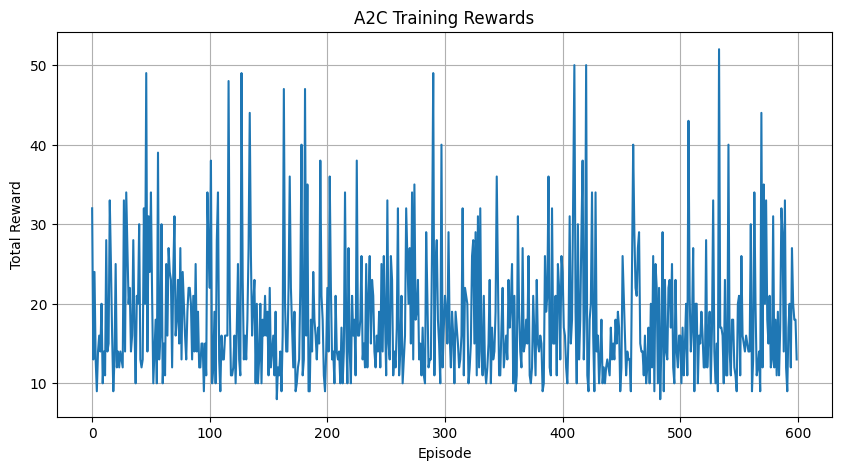

In [32]:
# ============================================================
# Plot Training Rewards
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Training Rewards")
plt.grid(True)
plt.show()

In [33]:
# ============================================================
# Evaluation
# ============================================================
eval_rewards = evaluate_agent(eval_env, actor, episodes=EVAL_EPISODES)

print("\nEvaluation on 5 episodes:")
for i, r in enumerate(eval_rewards, 1):
    print(f"Episode {i}: Total Reward = {r}")

print(f"\nAverage Evaluation Reward: {np.mean(eval_rewards):.2f}")

env.close()
eval_env.close()


Evaluation on 5 episodes:
Episode 1: Total Reward = 10.0
Episode 2: Total Reward = 10.0
Episode 3: Total Reward = 10.0
Episode 4: Total Reward = 10.0
Episode 5: Total Reward = 10.0

Average Evaluation Reward: 10.00
